# Lesson 194 · Analysis & report

Offline Python 3 standard-library evidence lab. The authored reference figures and scores below are not your kernel measurements. Your functions generate a complete report from the embedded frozen packet.

In [ ]:
# @colab-bootstrap
# Offline: no checkout, package installation, download, model, or paid API.
import base64, hashlib, io, json, math, tempfile, zipfile
from pathlib import Path
from collections import Counter
workspace=Path(tempfile.mkdtemp(prefix="l194-report-"))

<p class="eyebrow">YEAR 5 · LESSON 194 · ANALYSIS & REPORT</p>

# Explain what the evidence can support

**Your tangible win:** write a reproduction report that distinguishes a result, a possible explanation, and the experiment needed to test that explanation. This closes the reporting step of lessons 192–194; the model reproduction itself remains incomplete.

<div class="repro-status"><strong>Full reproduction: INCOMPLETE_SOURCE_PREPROCESSING_GATE.</strong> 0/21 measured tasks; 0/630 model evaluations. This lesson completes evidence analysis, not inference. $0 new cloud/API.</div>



From [L192](https://avistian.github.io/relational/lessons/0192-open-fm-setup-data.html), what must stay consistent between support and query preprocessing? From [L193](https://avistian.github.io/relational/lessons/0193-open-fm-full-task-set.html), what happens to a task mean if one required seed is missing? Looking ahead to analysis: what evidence would turn a suspected failure mode into a tested explanation?



**Mission connection.** A persuasive case for relational learning needs explanations a skeptic could test. A polished report that hides missing results weakens that case. Today's skill is deciding which sentence the evidence permits.

## 2 · Trace the model before explaining it

RDBLearn builds features by following relationships between database rows, then passes those features to a pretrained tabular predictor. **Support** means the labeled examples supplied at prediction time. A **query** is a row whose label must be predicted. A **cutoff** is the time beyond which information is unavailable for that prediction. **DFS**, deep feature synthesis, composes aggregations along relationship paths. The backend uses support examples without updating its pretrained weights. [Primary reading: RDBLearn v1, §3 and §5](https://arxiv.org/html/2602.18495v1#S3).

<figure class="repro-figure">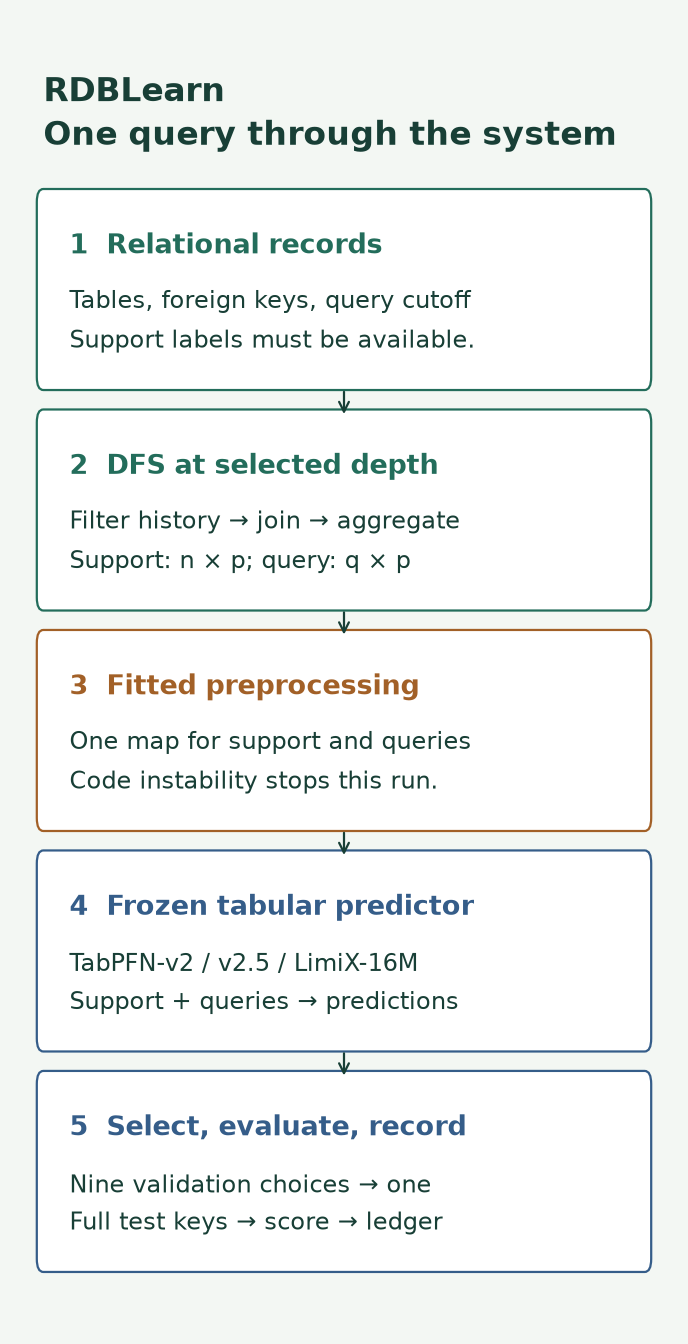<figcaption>RDBLearn recap from L193: relational records → DFS features → fitted map → frozen tabular predictor → validation selection and test scoring. Admission stopped at the fitted map.</figcaption></figure>

Follow one customer query: select records permitted by its cutoff; summarize linked transactions; encode support and query with the same fitted map; supply both to the frozen predictor; score its prediction. Depth selects how far feature construction follows relationships. Validation chooses depth and backend; the test split evaluates that choice. This is the intended pipeline, not a certification that all temporal checks have passed.

**Worked example — recorded source diagnostic.** Fit categories `b,c,d` as `0,1,2`. In the recorded environment, adding query category `a` expands and sorts the class list, shifting the known codes to `1,2,3`. Stored support still has the earlier meaning. Numeric controls remain unchanged. This identifies a representation consistency failure. It does not tell us whether any benchmark query triggers it or how a predictor's score changes. [Recorded observations](https://avistian.github.io/relational/labs/evidence/l194/packet/preprocessing.json).

**Held fixed:** known categories, fitted support and numeric controls. **Varied:** the unseen query category. **Measured:** codes, not predictions. L194 authenticates and replays this saved diagnostic; it does not rerun the upstream preprocessor.

## 3 · A difference is a question, not its explanation


<p>Predict: does a favorable published difference prove that relational structure caused the improvement? No. The compared pipelines differ in more than one component.</p>

**In plain terms.** First ask which score is better. Then ask what else changed between the two systems. These are different questions.

**Comparator fixed before analysis:** AutoGluon+DFS, the supervised pipeline with relational feature synthesis, in all 21 rows of Tables 1–3. This comparison asks how two complete pipelines rank in the published table. It does not isolate the value of adding relational structure: both already use it. The paper describes its comparison families in [§5](https://arxiv.org/html/2602.18495v1#S5).

**AUROC** measures how well a binary predictor ranks positives above negatives; larger is better. **MAE**, mean absolute error, averages absolute prediction errors in the target's units; smaller is better. Define an **oriented gap** so positive always favors RDBLearn:

- AUROC gap = RDBLearn score − comparator score.
- MAE gap = comparator error − RDBLearn error.

**Worked examples from the printed table.** Item churn: `.8188 − .7953 = +.0235` AUROC. Item lifetime value: `57.0000 − 48.5044 = +8.4956` target units of MAE reduction. The signs have the same interpretation; the magnitudes have different units. Neither supplies a causal explanation.

<figure class="repro-figure">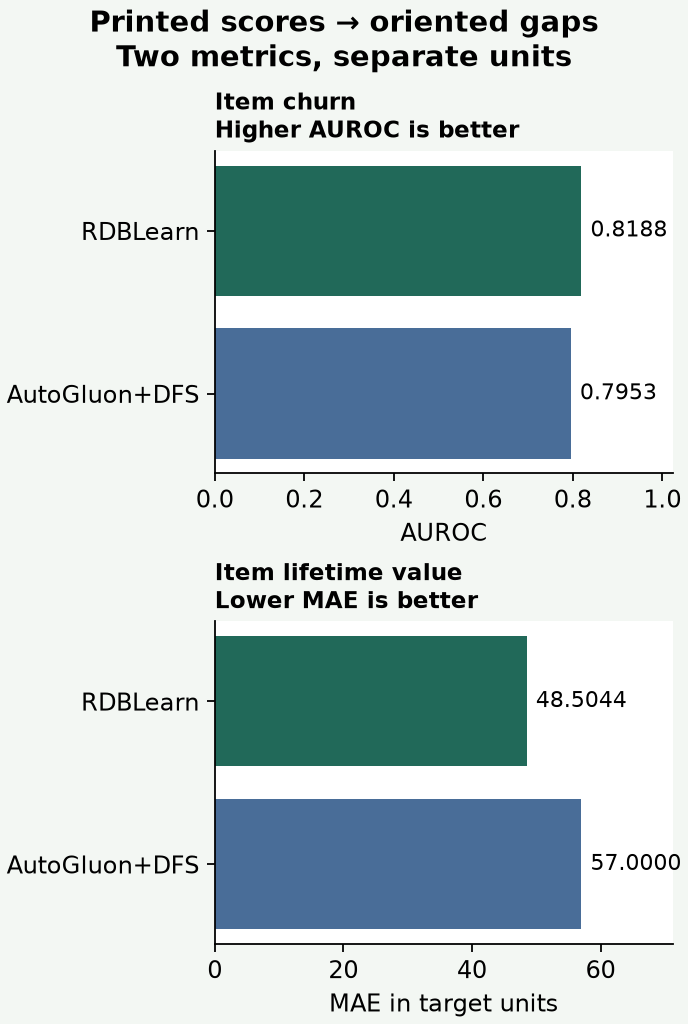<figcaption>Published reference examples only. Item churn: +0.0235 AUROC. Item lifetime value: +8.4956 target units of MAE reduction. Positive gaps favor RDBLearn; units cannot be pooled.</figcaption></figure>

The signed-gap function is your first TODO below.

A missing result returns `None` (an explicit absence), not zero. A zero gap means equal displayed scores; it is not evidence of equivalence. Rounded scalars cannot recover seed variability, paired prediction errors, or a significance test. Three tasks from one database are not three independent databases.

**Test what a printed tie can hide.** These are invented underlying AUROCs rounded to four decimals, not recovered paper values:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Model</th><th>Comparator</th><th>Hidden gap</th><th>Printed gap</th></tr></thead><tbody><tr><td>0.70004</td><td>0.69996</td><td>+0.00008</td><td>0</td></tr><tr><td>0.69996</td><td>0.70004</td><td>−0.00008</td><td>0</td></tr></tbody></table>

Both pairs print as `0.7000` versus `0.7000`. The displayed tie is compatible with either hidden direction; it supplies no seed variance. Keep the report's label “equal at printed precision.” A practical equivalence claim needs a prespecified margin and suitable uncertainty evidence beyond this rounding arithmetic.

**Transfer the trace.** Make the model result missing. `oriented_gap` returns `None`, and the summary increments missing rather than equal. Explain why replacing absence by zero would invent a measured tie.


## 4 · The complete report, including what did not run

The target remains the **RDBLearn v1 column across all 21 tasks**, with the released source pinned to commit `b5b03ebf8091547285a6e06cba53d2d1a40cb171`, release 0.1.2 and FastDFS 0.2.1. Per task, course seeds `0,1,2` each search depths `2,3,4` × TabPFNv2/TabPFNv2.5/LimiX-16M, official splits, and a 10,000-example support cap. These seeds extend repeatability; they are not recovered historical seeds. See the [inherited protocol](https://avistian.github.io/relational/labs/evidence/l194/packet/protocol.json).

That is `21 × 3 × 9 = 567` validation candidates and `21 × 3 = 63` selected tests. The source admission failure stopped all 630 model evaluations. The downstream model executor has not been implemented or validated. The full raw-data, feature availability, checkpoint and regression-normalization audits also remain unfinished. No new inference is authorized in this lesson.

| Task | Metric | Published RDBLearn | Published AutoGluon+DFS | Oriented gap | Fresh result |
|---|---|---:|---:|---:|---|
| relbench/rel-amazon/item-churn | AUROC | 0.8188 | 0.7953 | +0.0235 | NOT_RUN |
| relbench/rel-amazon/user-churn | AUROC | 0.6823 | 0.6666 | +0.0157 | NOT_RUN |
| relbench/rel-avito/user-clicks | AUROC | 0.6709 | 0.6191 | +0.0518 | NOT_RUN |
| relbench/rel-avito/user-visits | AUROC | 0.6569 | 0.6064 | +0.0505 | NOT_RUN |
| relbench/rel-hm/user-churn | AUROC | 0.6802 | 0.6802 | +0.0000 | NOT_RUN |
| relbench/rel-stack/user-badge | AUROC | 0.8430 | 0.8470 | -0.0040 | NOT_RUN |
| relbench/rel-stack/user-engagement | AUROC | 0.8935 | 0.8928 | +0.0007 | NOT_RUN |
| relbench/rel-trial/study-outcome | AUROC | 0.7167 | 0.6740 | +0.0427 | NOT_RUN |
| relbench/rel-amazon/item-ltv | MAE | 48.5044 | 57.0000 | +8.4956 | NOT_RUN |
| relbench/rel-amazon/user-ltv | MAE | 14.5290 | 16.2047 | +1.6757 | NOT_RUN |
| relbench/rel-avito/ad-ctr | MAE | 0.0341 | 0.0460 | +0.0119 | NOT_RUN |
| relbench/rel-event/user-attendance | MAE | 0.2393 | 0.2590 | +0.0197 | NOT_RUN |
| relbench/rel-hm/item-sales | MAE | 0.0630 | 0.0678 | +0.0048 | NOT_RUN |
| relbench/rel-stack/post-votes | MAE | 0.0676 | 0.0709 | +0.0033 | NOT_RUN |
| relbench/rel-trial/site-success | MAE | 0.4179 | 0.4396 | +0.0217 | NOT_RUN |
| relbench/rel-trial/study-adverse | MAE | 44.5186 | 43.6232 | -0.8954 | NOT_RUN |
| 4dbinfer/amazon/churn | AUROC | 0.7777 | 0.7291 | +0.0486 | NOT_RUN |
| 4dbinfer/outbrain/ctr-100k | AUROC | 0.5499 | 0.5494 | +0.0005 | NOT_RUN |
| 4dbinfer/retailrocket/cvr | AUROC | 0.8609 | 0.7343 | +0.1266 | NOT_RUN |
| 4dbinfer/stackexchange/post-upvote | AUROC | 0.8736 | 0.8849 | -0.0113 | NOT_RUN |
| 4dbinfer/stackexchange/user-churn | AUROC | 0.8774 | 0.8396 | +0.0378 | NOT_RUN |

**Published reference signs: 17 favorable, 3 unfavorable, 1 equal at printed precision.** These are descriptive signs from rounded published values. Every fresh mean and sample standard deviation (variation across required seeds) stays blank. The [complete report](https://avistian.github.io/relational/labs/evidence/l194/report.md) includes all task rows, limitations and continuation requirements; the [JSON report](https://avistian.github.io/relational/labs/evidence/l194/report.json) is generated by the same visible functions used in the notebook.

**Scope check.** Do not average AUROC with MAE, or raw MAEs measured in different target units. Regression normalization requires a verified reference error per task; those denominators remain `NOT_ESTABLISHED`. Missing benchmark results establish neither that the model wins nor that it loses.

## 5 · Turn each explanation into a test

A **mechanistic explanation** names an operation that could change the result. An **intervention** deliberately changes a specified input or operation. A **confounder** is another varying factor that could explain the observed difference. We can write testable plans now; executing them needs valid model results and a separately approved protocol.

| Suspected reason | Vary or stratify | Hold fixed | Measure and limit |
|---|---|---|---|
| Label coverage | Nested support sizes using only labels available by each cutoff | Query set, checkpoint, features, depth, preprocessing and paired seeds | Per-task score changes. Tests context sensitivity, not pretraining scale. |
| Schema information | Remove one specified relationship path | Support, queries, checkpoint, remaining paths and preprocessing policy | Paired change after the feature intervention. Tests that path in this pipeline, not arbitrary schema transfer. |
| Cold start | Prespecify entities seen/unseen in allowed support history | Same fitted predictor, cutoff policy and scorer | Sizes, label counts and separate scores. An observational subgroup gap may reflect degree, time or label differences. |

**Worked hypothesis.** “Sparse support hurts” predicts improvement when support grows while queries and the predictor stay fixed. Use nested samples so the smaller support is contained in the larger set. Freeze the comparison before viewing test results. If the predicted improvement does not appear, the result challenges this hypothesis for the tested conditions. If it appears, it still does not explain all 21 tasks.

**Cold-start caution.** An entity unseen in labeled support can still have historical neighbors. State which kind of novelty you mean. AUROC is undefined for a subgroup containing only one class; keep its label counts and do not invent a score. These plans are course analysis proposals, not experiments reported by the paper or completed here.

**Predict before changing the evidence selector:** what additional claim does a source counterexample permit compared with a missing benchmark result?


<p>Published table → descriptive comparison. Saved source diagnostic → code-invariant failure. Unrun benchmark → no performance conclusion. Proposed intervention → untested hypothesis.</p>

## 6 · Build, challenge, defend

[Student notebook](https://avistian.github.io/relational/labs/0194-open-fm-analysis-report.ipynb) · [executed solution](https://avistian.github.io/relational/labs/solutions/0194-open-fm-analysis-report.ipynb) · [readable lab](https://avistian.github.io/relational/labs/html/0194-open-fm-analysis-report.html) · [field guide](https://avistian.github.io/relational/reference/open-fm-analysis-report.html).

Implement `oriented_gap`, `evidence_license` and `summarize_comparisons`. Each function feeds the full 21-task report. Then delete a task, insert a nonfinite score, or try an unsupported evidence type: the checks must refuse the claim. The portable notebook embeds its evidence and uses only Python's standard library for replay; no account, download or model is needed.

**Your report has six parts:** question and frozen protocol; complete per-task results; uncertainty; diagnostic and competing explanations; limitations; the next decisive experiment. Write an abstract that says the source diagnostic is informative while benchmark attribution is unestablished. Explain why the 17 favorable published signs do not complete the Year 5 reproduction exit.


<p>Write your own explanation before checking: the source diagnostic establishes code instability under recorded conditions; the published table supplies descriptive comparisons; no fresh predictions exist to measure benchmark effects.</p>

**Execution budget:** $0 new cloud/API spend, 1,800 aggregate local execution seconds including failed attempts and delivery checks. [Reproduction contract and commands](https://avistian.github.io/relational/labs/l194-reproduction.md). A repaired pipeline needs a separately named protocol, data and checkpoint audits, a validated runner and a complete-grid cost forecast; silently reducing tasks, seeds or candidates would change the target.

The report is prepared; your written defense remains `PENDING_WRITTEN_DEFENSE`. Ask me about any unclear step, or send your abstract for feedback. [Lesson 195](https://avistian.github.io/relational/lessons/0195-thesis-stress-test.html) stress-tests the thesis using the strongest available evidence. Author checks, learner mastery, full reproduction, live Colab and deployment are separate claims.


## PROVIDED · Authenticated packet
The archive contains the complete inherited task and seed ledgers, paper HTML, recorded diagnostic and source identity. Hash equality establishes byte identity to this embedded snapshot, not historical truth or benchmark validity.

In [ ]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='f58dc1dc5d5e8213452583bcdf3ab1cecd4c68e25a774034ff50923f863d61c4'
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():
        if not (workspace/name).resolve().is_relative_to(workspace.resolve()): raise ValueError("Unsafe archive path")
    z.extractall(workspace)
packet=workspace/"packet"
manifest=json.loads((workspace/"input-manifest.json").read_text())

## TODO · oriented_gap
Positive favors the model: AUROC uses model minus comparator; MAE reverses it. Accept nonnegative finite numbers (AUROC at most 1), reject bools and unknown metrics; null in either input returns null after validating the other.

Predict one failure before running the CHECK. Your function is called by the full report operator.

In [ ]:
def oriented_gap(metric, model, comparator):
    raise NotImplementedError('oriented_gap')

### CHECK · Meaningful boundaries

In [ ]:
assert abs(oriented_gap('AUROC',.8188,.7953)-.0235)<1e-12
assert abs(oriented_gap('MAE',48.5044,57)-8.4956)<1e-12
assert oriented_gap('MAE',None,57) is None
try: oriented_gap('AUROC',1.1,.5)
except ValueError: pass
else: raise AssertionError('Invalid AUROC accepted')
print("Contract PASS")

## TODO · evidence_license
Map PUBLISHED_TABLE → DESCRIPTIVE_REFERENCE_ONLY; SAVED_SOURCE_DIAGNOSTIC → SOURCE_INVARIANT_FAILURE_ONLY; UNRUN_BENCHMARK → NO_PERFORMANCE_CONCLUSION; PROPOSED_INTERVENTION → HYPOTHESIS_NOT_TESTED. Reject every other kind. Explain the reason for each restriction before coding.

Predict one failure before running the CHECK. Your function is called by the full report operator.

In [ ]:
def evidence_license(kind):
    raise NotImplementedError('evidence_license')

### CHECK · Meaningful boundaries

In [ ]:
assert evidence_license('UNRUN_BENCHMARK')=='NO_PERFORMANCE_CONCLUSION'
assert evidence_license('SAVED_SOURCE_DIAGNOSTIC')=='SOURCE_INVARIANT_FAILURE_ONLY'
try: evidence_license('PROVEN_BENCHMARK_CAUSE')
except ValueError: pass
else: raise AssertionError('Unsupported claim accepted')
print("Contract PASS")

## TODO · summarize_comparisons
Require nonempty unique expected IDs and exactly one row per task. Count positive/negative/zero/null gaps as higher/lower/equal_at_printed_precision/missing. Reject nonnumeric, bool or nonfinite gaps. Return tasks, the four counts and scope="Descriptive signs; no pooled metric or significance claim". Never average gap magnitudes.

Predict one failure before running the CHECK. Your function is called by the full report operator.

In [ ]:
def summarize_comparisons(rows, expected_ids):
    raise NotImplementedError('summarize_comparisons')

### CHECK · Meaningful boundaries

In [ ]:
toy=[dict(task='a',gap=.1),dict(task='b',gap=None),dict(task='c',gap=0)]
s=summarize_comparisons(toy,['a','b','c'])
assert (s['higher'],s['missing'],s['equal_at_printed_precision'])==(1,1,1)
try: summarize_comparisons(toy[:-1],['a','b','c'])
except ValueError: pass
else: raise AssertionError('Missing task hidden')
print("Contract PASS")

## PROVIDED · Complete report operator
Read how paper rows are matched by task identity, how missing scores are preserved, and how your three functions control the resulting report. No predictor is executed.

In [ ]:
def build_report(packet, manifest, gap_fn, license_fn, summary_fn):
    import hashlib,json,itertools
    from collections import Counter
    from html.parser import HTMLParser
    for name,digest in manifest['files'].items():
        if Path(name).name != name or hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Packet integrity failure: '+name)
    read=lambda name:json.loads((packet/name).read_text())
    tasks=read('tasks.json');prior=read('prior-report.json');protocol=read('protocol.json');runs=read('runs.json')
    if len(tasks)!=21 or len({t['id'] for t in tasks})!=21:raise ValueError('Incomplete task set')
    prior_manifest=read('prior-manifest.json')
    for name,digest in prior_manifest['files'].items():
        if manifest['files'].get(name)!=digest:raise ValueError('Original packet identity changed')
    if protocol['seeds']!=[0,1,2] or protocol['depths']!=[2,3,4] or protocol['backends']!=['TabPFN-v2','TabPFN-v2.5','LimiX-16M']:raise ValueError('Protocol changed')
    expected=Counter((t['id'],s) for t in tasks for s in protocol['seeds'])
    if Counter((r['task'],r['seed']) for r in runs)!=expected:raise ValueError('Incomplete seed set')
    if any(r['status']!='NOT_RUN' or r['score'] is not None for r in runs):raise ValueError('Frozen unrun ledger changed')
    if prior['executed_model_evaluations']!=0 or prior['status']!='INCOMPLETE_SOURCE_PREPROCESSING_GATE':raise ValueError('Prior status changed')
    if Counter(r['task'] for r in prior['task_results'])!=Counter(t['id'] for t in tasks):raise ValueError('Prior task set mismatch')
    if any(r['mean'] is not None or r['sample_sd'] is not None or r['completed_seeds']!=0 for r in prior['task_results']):raise ValueError('Invented measured result')
    if len(read('validation-schedule.json'))!=567 or len(read('test-schedule.json'))!=63:raise ValueError('Schedule coverage changed')
    class Tables(HTMLParser):
        def __init__(self):super().__init__();self.tables=[];self.table=None;self.row=None;self.cell=None
        def handle_starttag(self,tag,attrs):
            if tag=='table':self.table=[]
            if tag=='tr' and self.table is not None:self.row=[]
            if tag in ('td','th') and self.row is not None:self.cell=[]
        def handle_data(self,data):
            if self.cell is not None:self.cell.append(data)
        def handle_endtag(self,tag):
            if tag in ('td','th') and self.cell is not None:self.row.append(' '.join(''.join(self.cell).split()));self.cell=None
            if tag=='tr' and self.row is not None:self.table.append(self.row);self.row=None
            if tag=='table' and self.table is not None:self.tables.append(self.table);self.table=None
    parser=Tables();parser.feed((packet/'paper.html').read_text());references={};table_id=0
    comparator=read('analysis-protocol.json')['comparator']
    if comparator!='AutoGluon+DFS':raise ValueError('Unapproved comparator')
    for table in parser.tables:
        header=next((r for r in table if 'Dataset' in r and 'RDBLearn' in r),None)
        if header is None:continue
        table_id+=1;dataset=''
        for row in table[table.index(header)+1:]:
            if len(row)!=len(header):continue
            dataset=row[0] or dataset;task=row[1].split(' (')[0].lower();key=(table_id,dataset.lower(),task)
            if key in references:raise ValueError('Duplicate paper row')
            references[key]=(float(row[header.index('RDBLearn')]),float(row[header.index(comparator)]))
    if len(references)!=21:raise ValueError('Paper extraction coverage')
    rows=[]
    for task in tasks:
        model,base=references[(task['paper_table'],task['dataset'],task['task'])]
        if model!=task['paper_score']:raise ValueError('Target mismatch')
        gap=gap_fn(task['metric'],model,base)
        rows.append(dict(task=task['id'],metric=task['metric'],group=task['group'],paper_model=model,paper_comparator=base,gap=gap,published_license=license_fn('PUBLISHED_TABLE'),fresh_gap=gap_fn(task['metric'],None,None),fresh_mean=None,fresh_sd=None,completed_seeds=0,status='NOT_RUN',performance_license=license_fn('UNRUN_BENCHMARK'),attribution='NOT_ESTABLISHED'))
    probe=read('preprocessing.json');observations=probe['observations']
    changed=[sum(a!=b for a,b in zip(o['before'],o['after'])) for o in observations]
    if changed!=[3,0,3,0] or any(o['numeric_before']!=o['numeric_after'] for o in observations):raise ValueError('Diagnostic mismatch')
    plans=[dict(axis='label_coverage',hypothesis='More available labeled support improves prediction',vary='Nested support sizes sampled only from labels available at each cutoff',hold_fixed='Same queries, features, checkpoint, depth, preprocessing, seed pairing and evaluation rule',measure='Per-task paired AUROC or MAE change across complete seeds',limitation='Context sensitivity is not pretraining scale or cross-database superiority'),dict(axis='schema_information',hypothesis='A specified join path supplies useful predictive information',vary='Remove that path under a declared feature intervention',hold_fixed='Same queries, support labels, checkpoint, preprocessing policy, seed pairing and remaining paths',measure='Per-task paired score change with and without the path',limitation='Ablation tests path information under this pipeline, not arbitrary schema robustness'),dict(axis='cold_start',hypothesis='Performance differs for entities unseen in support history',vary='Prespecified cold/warm strata using only past entity membership',hold_fixed='Same fitted predictor, task cutoff policy and scoring implementation',measure='Stratum sizes, label counts and separate scores; AUROC undefined for single-class strata',limitation='Observational subgroup comparison; degree, time and labels may confound the difference')]
    for plan in plans:plan.update(status='NOT_RUN',license=license_fn('PROPOSED_INTERVENTION'))
    return dict(name='L194 complete analysis and report',status=prior['status'],task_count=21,validation_slots=567,test_slots=63,executed_model_evaluations=0,comparator=comparator,reference_summary=summary_fn(rows,[t['id'] for t in tasks]),task_results=rows,source_diagnostic=dict(scope='Replay of L193 synthetic observations',changed_known_codes=changed,license=license_fn('SAVED_SOURCE_DIAGNOSTIC'),real_task_occurrence='NOT_ESTABLISHED',score_effect='NOT_ESTABLISHED'),intervention_plans=plans,regression_normalization='NOT_ESTABLISHED',fresh_inference='NOT_RUN',whole_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE',cloud_usd=0)

In [ ]:
def report_markdown(report):
    lines=['# RDBLearn reproduction — analysis report','', '**Model reproduction: '+report['status']+'**. Completed tasks: 0/21; model evaluations: 0/630.','', '## Question and protocol','', 'Can the complete RDBLearn v1 Tables 1–3 column be reproduced? The frozen L193 plan uses all 21 tasks, three course seeds, depths 2/3/4 and TabPFNv2/v2.5/LimiX-16M: 567 validation candidates, 63 selected tests. Source commit b5b03ebf8091547285a6e06cba53d2d1a40cb171, release 0.1.2, FastDFS 0.2.1; official splits and support cap 10000. Course seeds are a disclosed extension.','', '## Results and uncertainty','', 'All fresh scores and their seed SDs remain null. Positive reference gaps favor RDBLearn; AUROC uses model minus comparator, MAE uses comparator minus model. Comparator fixed before analysis: AutoGluon+DFS. These are rounded published values, not fresh or paired measurements. No statistical significance or causal claim follows. No raw-MAE or mixed-metric average is computed.','', '| Task | Metric | Published RDBLearn | Published AutoGluon+DFS | Oriented reference gap | Fresh result | Attribution |','|---|---|---:|---:|---:|---|---|']
    for row in report['task_results']:lines.append(f"| {row['task']} | {row['metric']} | {row['paper_model']:.4f} | {row['paper_comparator']:.4f} | {row['gap']:+.4f} | NOT_RUN | NOT_ESTABLISHED |")
    s=report['reference_summary'];lines+=['',f"At printed precision: {s['higher']} favorable, {s['lower']} unfavorable, {s['equal_at_printed_precision']} equal. Counts give each task one vote; dependent tasks and heterogeneous methods prevent a causal or significance interpretation.",'','## Diagnostic and explanation boundary','','Recorded synthetic source observations change known category codes in two of four interventions; numeric controls are unchanged. This justifies the declared source-admission stop. It does not establish occurrence or score impact on any real task. L194 replays these observations; it does not freshly execute the upstream preprocessor.','','## Testable follow-up studies (all NOT_RUN)']
    for plan in report['intervention_plans']:lines+=['', '### '+plan['axis'], '', *[f"**{k.replace('_',' ').capitalize()}:** {plan[k]}" for k in ('hypothesis','vary','hold_fixed','measure','limitation')]]
    lines+=['','## Limitations and resumption','','Resolve source/preprocessing identity in a separately named repair protocol; audit raw data, labels, features and temporal availability; authenticate checkpoint bytes; establish regression denominators; implement and validate the backend executor; measure full-grid cost before dispatch. Preserve all tasks, seeds and candidates. No backend pretraining or comparator retraining is included. Whole-paper reproduction remains NOT_RUN and historical identity NOT_ESTABLISHED.','','L194 approved budget: $0 cloud/API and 1800 aggregate local execution seconds. L193’s $10 ceiling was not a demonstrated full-run cost estimate. Learner defense remains PENDING_WRITTEN_DEFENSE.','','Primary source: [RDBLearn v1](https://arxiv.org/html/2602.18495v1). Input hashes: [manifest](input-manifest.json). Structured result: [report](report.json).']
    return '\n'.join(lines)+'\n'

## CHECK · Full 21-task report
Exact agreement authenticates this analysis. It does not establish full model reproduction.

In [ ]:
report=build_report(packet,manifest,oriented_gap,evidence_license,summarize_comparisons)
assert report==json.loads('{"cloud_usd": 0, "comparator": "AutoGluon+DFS", "executed_model_evaluations": 0, "fresh_inference": "NOT_RUN", "historical_identity": "NOT_ESTABLISHED", "intervention_plans": [{"axis": "label_coverage", "hold_fixed": "Same queries, features, checkpoint, depth, preprocessing, seed pairing and evaluation rule", "hypothesis": "More available labeled support improves prediction", "license": "HYPOTHESIS_NOT_TESTED", "limitation": "Context sensitivity is not pretraining scale or cross-database superiority", "measure": "Per-task paired AUROC or MAE change across complete seeds", "status": "NOT_RUN", "vary": "Nested support sizes sampled only from labels available at each cutoff"}, {"axis": "schema_information", "hold_fixed": "Same queries, support labels, checkpoint, preprocessing policy, seed pairing and remaining paths", "hypothesis": "A specified join path supplies useful predictive information", "license": "HYPOTHESIS_NOT_TESTED", "limitation": "Ablation tests path information under this pipeline, not arbitrary schema robustness", "measure": "Per-task paired score change with and without the path", "status": "NOT_RUN", "vary": "Remove that path under a declared feature intervention"}, {"axis": "cold_start", "hold_fixed": "Same fitted predictor, task cutoff policy and scoring implementation", "hypothesis": "Performance differs for entities unseen in support history", "license": "HYPOTHESIS_NOT_TESTED", "limitation": "Observational subgroup comparison; degree, time and labels may confound the difference", "measure": "Stratum sizes, label counts and separate scores; AUROC undefined for single-class strata", "status": "NOT_RUN", "vary": "Prespecified cold/warm strata using only past entity membership"}], "learner": "PENDING_WRITTEN_DEFENSE", "name": "L194 complete analysis and report", "reference_summary": {"equal_at_printed_precision": 1, "higher": 17, "lower": 3, "missing": 0, "scope": "Descriptive signs; no pooled metric or significance claim", "tasks": 21}, "regression_normalization": "NOT_ESTABLISHED", "source_diagnostic": {"changed_known_codes": [3, 0, 3, 0], "license": "SOURCE_INVARIANT_FAILURE_ONLY", "real_task_occurrence": "NOT_ESTABLISHED", "scope": "Replay of L193 synthetic observations", "score_effect": "NOT_ESTABLISHED"}, "status": "INCOMPLETE_SOURCE_PREPROCESSING_GATE", "task_count": 21, "task_results": [{"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.023499999999999965, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.7953, "paper_model": 0.8188, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/item-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.015700000000000047, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6666, "paper_model": 0.6823, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/user-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.05180000000000007, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6191, "paper_model": 0.6709, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/user-clicks"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.05049999999999999, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6064, "paper_model": 0.6569, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/user-visits"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.6802, "paper_model": 0.6802, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-hm/user-churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.0040000000000000036, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.847, "paper_model": 0.843, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/user-badge"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0006999999999999229, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.8928, "paper_model": 0.8935, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/user-engagement"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.04269999999999996, "group": "relbench_classification", "metric": "AUROC", "paper_comparator": 0.674, "paper_model": 0.7167, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/study-outcome"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 8.495600000000003, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 57.0, "paper_model": 48.5044, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/item-ltv"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 1.675699999999999, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 16.2047, "paper_model": 14.529, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-amazon/user-ltv"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0119, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.046, "paper_model": 0.0341, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-avito/ad-ctr"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.019699999999999995, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.259, "paper_model": 0.2393, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-event/user-attendance"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.004799999999999999, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.0678, "paper_model": 0.063, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-hm/item-sales"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.0033000000000000113, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.0709, "paper_model": 0.0676, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-stack/post-votes"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.021699999999999997, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 0.4396, "paper_model": 0.4179, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/site-success"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.8954000000000022, "group": "relbench_regression", "metric": "MAE", "paper_comparator": 43.6232, "paper_model": 44.5186, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "relbench/rel-trial/study-adverse"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.04859999999999998, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.7291, "paper_model": 0.7777, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/amazon/churn"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.000500000000000056, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.5494, "paper_model": 0.5499, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/outbrain/ctr-100k"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.12660000000000005, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.7343, "paper_model": 0.8609, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/retailrocket/cvr"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": -0.011299999999999977, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.8849, "paper_model": 0.8736, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/stackexchange/post-upvote"}, {"attribution": "NOT_ESTABLISHED", "completed_seeds": 0, "fresh_gap": null, "fresh_mean": null, "fresh_sd": null, "gap": 0.037799999999999945, "group": "4dbinfer_classification", "metric": "AUROC", "paper_comparator": 0.8396, "paper_model": 0.8774, "performance_license": "NO_PERFORMANCE_CONCLUSION", "published_license": "DESCRIPTIVE_REFERENCE_ONLY", "status": "NOT_RUN", "task": "4dbinfer/stackexchange/user-churn"}], "test_slots": 63, "validation_slots": 567, "whole_paper": "NOT_RUN"}')
Path("l194-report.json").write_text(json.dumps(report,indent=2))
Path("l194-report.md").write_text(report_markdown(report))
print(report_markdown(report))

## EXIT · Write and defend
Write a three-sentence abstract and a controlled follow-up. Specify varied factor, fixed alternatives, metric, falsifying observation and limitation. Explain why cold/warm strata are observational and why a source repair changes the protocol. Send your defense to the teacher; successful author execution does not certify learning.

In [ ]:
submission=dict(learner="PENDING_WRITTEN_DEFENSE",abstract="",vary="",hold_fixed="",measure="",falsifying_observation="",limitation="",repair_boundary="")
Path("l194-submission.json").write_text(json.dumps(submission,indent=2))